This is a part 2 to the Weather Bench guide that explored how to navigate climate datasets. This guide is heavier on building machine learning models and forecasting using time series models. This guide goes through various models, using various strategies that can help you create your own models.

#### Importing & Downloading

In [ ]:
!pip install shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 569 kB 5.3 MB/s 


In [ ]:
!pip install sktime

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 7.0 MB 5.3 MB/s 


In [ ]:
!pip install skforecast

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 169 kB 5.1 MB/s 
     |████████████████████████████████| 283 kB 39.4 MB/s 
     |████████████████████████████████| 100 kB 8.9 MB/s 
     |████████████████████████████████| 308 kB 43.9 MB/s 
     |████████████████████████████████| 11.2 MB 45.3 MB/s 
     |████████████████████████████████| 78 kB 5.8 MB/s 
     |████████████████████████████████| 209 kB 36.1 MB/s 
     |████████████████████████████████| 81 kB 4.7 MB/s 
     |████████████████████████████████| 965 kB 34.5 MB/s 
     |████████████████████████████████| 42 kB 1.5 MB/s 
     |████████████████████████████████| 78 kB 7.2 MB/s 
     |████████████████████████████████| 147 kB 38.8 MB/s 
     |████████████████████████████████| 50 kB 5.0 MB/s 
     |████████████████████████████████| 112 kB 39.1 MB/s 
  Created wheel for pyperclip: filename=pyperclip-1.8.2-py3-none-any.whl size=11137 sha256=28eff941c

In [ ]:
import xarray as xr # Helps make Net CDF files understandable
import matplotlib.pyplot as plt # For making data visualizations
import numpy as np # To understand data values
import pandas as pd # For dataframes
from sklearn.model_selection import train_test_split # To split data into training and test data
from sklearn import metrics # To score our models
from sklearn import linear_model # To make our linear regression model
from sklearn.linear_model import LinearRegression # To make our linear regression model
from sklearn.metrics import mean_squared_error # to use mse to score our models
from sklearn.ensemble import RandomForestRegressor # for building the random forest model
from sklearn.model_selection import GridSearchCV # To use for finding the best parameters for our random forest model
from sklearn.tree import export_graphviz # To visualize decision trees
import graphviz # To visualize decision trees
from IPython.display import Image # To visualize decision trees
import sklearn
import shap
import xgboost as xgb
from xgboost import plot_importance, plot_tree
import datetime
from datetime import datetime
from sklearn.model_selection import KFold
import seaborn as sns
import sktime
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
import skforecast
from skforecast.ForecasterAutoreg import ForecasterAutoreg
from skforecast.ForecasterAutoregCustom import ForecasterAutoregCustom
from skforecast.ForecasterAutoregMultiOutput import ForecasterAutoregMultiOutput
from statsmodels.graphics.tsaplots import plot_acf
from pandas.plotting import lag_plot

In [ ]:
#Downloading the data through a link (note: it might take a few minutes)
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Fgeopotential_500&files=geopotential_500_5.625deg.zip" -O geopotential_500_5.625deg.zip --no-check-certificate

--2022-10-23 15:37:05--  https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Fgeopotential_500&files=geopotential_500_5.625deg.zip
Resolving dataserv.ub.tum.de (dataserv.ub.tum.de)... 138.246.224.34, 2001:4ca0:800::8af6:e022
Connecting to dataserv.ub.tum.de (dataserv.ub.tum.de)|138.246.224.34|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 1532774663 (1.4G) [application/zip]
Saving to: ‘geopotential_500_5.625deg.zip’

geopotential_500_5. 100%[===================>]   1.43G  23.8MB/s    in 62s     

2022-10-23 15:38:08 (23.6 MB/s) - ‘geopotential_500_5.625deg.zip’ saved [1532774663/1532774663]



In [ ]:
# Make a folder for geopotential
!mkdir -p geopotential_500
# Unzip the geopotential_500_5.625deg zip file and place it in the folder we made above
!unzip -d geopotential_500/ geopotential_500_5.625deg.zip

Archive:  geopotential_500_5.625deg.zip
  inflating: geopotential_500/geopotential_500hPa_1979_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1980_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1981_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1982_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1983_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1984_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1985_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1986_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1987_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1988_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1989_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1990_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1991_5.625deg.nc  
  inflating: geopotential_500/geopotential_500hPa_1992_5.625deg

In [ ]:
# open the dataset, putting it in a variable called z500
z500 = xr.open_mfdataset('geopotential_500/*.nc', combine='by_coords')
# explain parameter, combine

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
z500.coords['lon'] = (z500.coords['lon'] + 180) % 360 - 180
z500 = z500.sortby(z500.lon)

Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]


In [ ]:
!wget "https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftemperature_850&files=temperature_850_5.625deg.zip" -O temperature_850_5.625deg.zip --no-check-certificate

--2022-10-23 15:38:54--  https://dataserv.ub.tum.de/s/m1524895/download?path=%2F5.625deg%2Ftemperature_850&files=temperature_850_5.625deg.zip
Resolving dataserv.ub.tum.de (dataserv.ub.tum.de)... 138.246.224.34, 2001:4ca0:800::8af6:e022
Connecting to dataserv.ub.tum.de (dataserv.ub.tum.de)|138.246.224.34|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 2254621588 (2.1G) [application/zip]
Saving to: ‘temperature_850_5.625deg.zip’

temperature_850_5.6 100%[===================>]   2.10G  23.6MB/s    in 92s     

2022-10-23 15:40:28 (23.3 MB/s) - ‘temperature_850_5.625deg.zip’ saved [2254621588/2254621588]



In [ ]:
!mkdir -p temperature_850
!unzip -d temperature_850/ temperature_850_5.625deg.zip

Archive:  temperature_850_5.625deg.zip
  inflating: temperature_850/temperature_850hPa_1979_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1980_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1981_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1982_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1983_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1984_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1985_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1986_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1987_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1988_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1989_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1990_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1991_5.625deg.nc  
  inflating: temperature_850/temperature_850hPa_1992_5.625deg.nc  
  inflating: temperatur

In [ ]:
temp = xr.open_mfdataset('temperature_850/*.nc', combine='by_coords')

In [ ]:
# Converting 0 to 360 longitude values to -180 to 180
temp.coords['lon'] = (temp.coords['lon'] + 180) % 360 - 180
temp = z500.sortby(temp.lon)

Models Leaderboard

This will let us compare RMSE scores and understand how to determine what models are good and which are bad.

https://github.com/pangeo-data/WeatherBench

#####- Maybe add a screenshot instead

## Our First Model

In [ ]:
# This is a place in Kyrgyzstan
data = z500.z.sel(lon='78.75',lat='42.1875')
# We are only using the data from 2000 to 2018 because the full data is quite large and causes the models to be slow to run
data = data.sel(time=slice('2000','2018'))

In [ ]:
# turning the data into a dataframe
df = data.to_dataframe()

In [ ]:
df
# We have level, lon, and lat columns which all have constant values.

,level,lon,lat,z
time,,,,
2000-01-01 00:00:00,500,78.75,42.1875,55102.500000
2000-01-01 01:00:00,500,78.75,42.1875,55110.171875
2000-01-01 02:00:00,500,78.75,42.1875,55125.500000
2000-01-01 03:00:00,500,78.75,42.1875,55171.515625
2000-01-01 04:00:00,500,78.75,42.1875,55179.191406
...,...,...,...,...
2018-12-31 19:00:00,500,78.75,42.1875,54983.343750
2018-12-31 20:00:00,500,78.75,42.1875,54960.375000
2018-12-31 21:00:00,500,78.75,42.1875,54975.687500


In [ ]:
# Let's drop these columns because we don't need them and they may actually cause our models to be less precise.
df = df.drop(['level','lon','lat'],axis=1)

In [ ]:
df

,z
time,
2000-01-01 00:00:00,55102.500000
2000-01-01 01:00:00,55110.171875
2000-01-01 02:00:00,55125.500000
2000-01-01 03:00:00,55171.515625
2000-01-01 04:00:00,55179.191406
...,...
2018-12-31 19:00:00,54983.343750
2018-12-31 20:00:00,54960.375000
2018-12-31 21:00:00,54975.687500


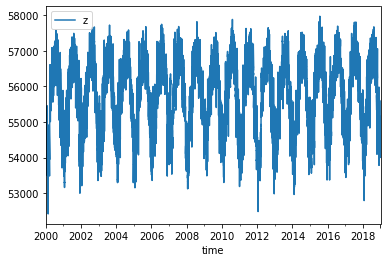

In [ ]:
df.plot()

We can recognize a seasonal trend in our data through this plot.

In [ ]:
# Let's create a function that creates different features of time
def features(df):
  df['hour']=df.index.hour
  df['dayofweek']=df.index.dayofweek
  df['quarter'] = df.index.quarter
  df['month'] = df.index.month
  df['year'] = df.index.year
  df['dayofyear'] = df.index.dayofyear
  df['day'] = df.index.day
  df['weekofyear'] = df.index.isocalendar().week.astype(int)
  return df

In [ ]:
features(df)

,z,hour,dayofweek,quarter,month,year,dayofyear,day,weekofyear
time,,,,,,,,,
2000-01-01 00:00:00,55102.500000,0,5,1,1,2000,1,1,52
2000-01-01 01:00:00,55110.171875,1,5,1,1,2000,1,1,52
2000-01-01 02:00:00,55125.500000,2,5,1,1,2000,1,1,52
2000-01-01 03:00:00,55171.515625,3,5,1,1,2000,1,1,52
2000-01-01 04:00:00,55179.191406,4,5,1,1,2000,1,1,52
...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,54983.343750,19,0,4,12,2018,365,31,1
2018-12-31 20:00:00,54960.375000,20,0,4,12,2018,365,31,1
2018-12-31 21:00:00,54975.687500,21,0,4,12,2018,365,31,1


In [ ]:
# Our training data will be from 2000 to 2015
train = df.loc[df.index<='01-01-2015']
# Our test data will be from 2015 to end (2018)
test = df.loc[df.index>'01-01-2015']

In [ ]:
# will have all the features of time that we created through the features function
X_train = train[['hour','dayofweek','quarter','month','year','dayofyear','day', 'weekofyear']]
# The target variable we want to predict for
y_train = train[['z']]
X_test = test[['hour','dayofweek','quarter','month','year','dayofyear','day', 'weekofyear']]
y_test = test[['z']]

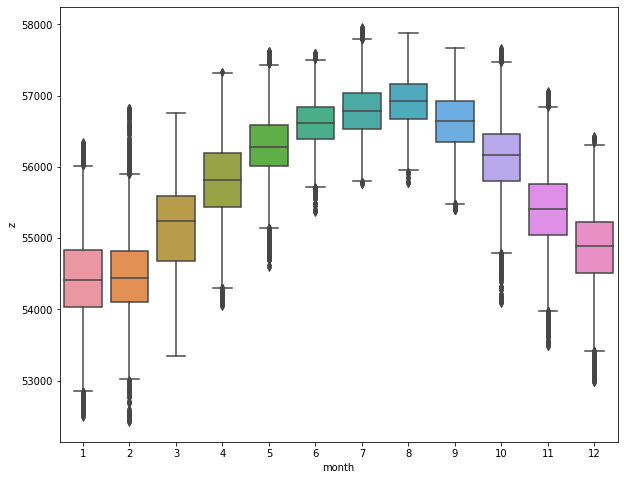

In [ ]:
fig,ax = plt.subplots(figsize=(10,8))
sns.boxplot(data=df,x='month',y='z')

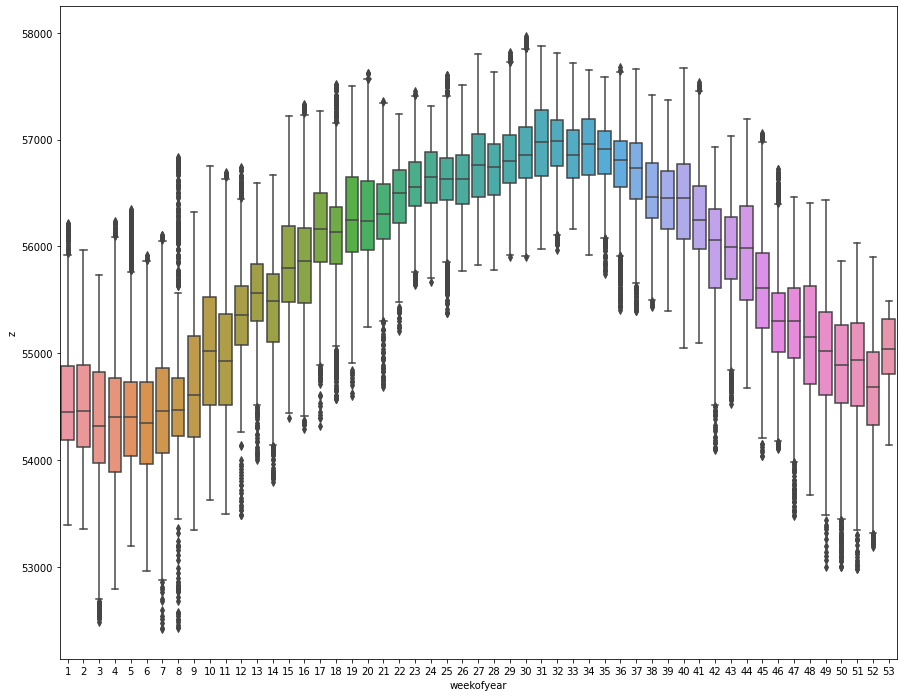

In [ ]:
fig,ax = plt.subplots(figsize=(15,12))
sns.boxplot(data=df,x='weekofyear',y='z')

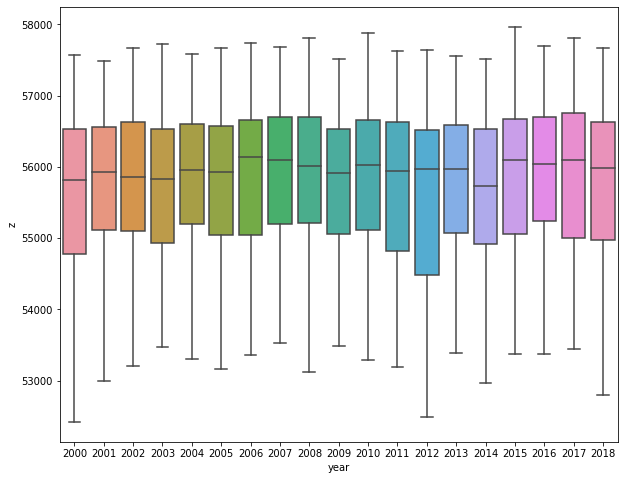

In [ ]:
fig,ax = plt.subplots(figsize=(10,8) )
sns.boxplot(data=df,x='year',y='z')

This is an XGBoost (Extreme Gradient Boosting) model. This model uses ensemble learning, as decision trees are added one at a time, improving each time as prediction errors are corrected. This model utilises the gradient descent optimization algorithm & differentiable loss function.

The benefits to this model is that it is comparitively faster to execute and is therefore more computationally effective, as well as a good model performance.

In [ ]:
xg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       min_samples_leaf=1,
                       max_leaf_nodes=10,
                       n_estimators=900,
                       early_stopping_rounds=10,
                       max_depth=3,
                       colsample_bytree = 0.4,
                       subsample = 0.7,
                       learning_rate=0.01)
xg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100)

[00:59:34] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:55228.9	validation_1-rmse:55330.2
[100]	validation_0-rmse:20222.5	validation_1-rmse:20323.6
[200]	validation_0-rmse:7415.99	validation_1-rmse:7521.79
[300]	validation_0-rmse:2749.35	validation_1-rmse:2862.15
[400]	validation_0-rmse:1094.47	validation_1-rmse:1212.45
[500]	validation_0-rmse:584.794	validation_1-rmse:694.274
[600]	validation_0-rmse:474.436	validation_1-rmse:558.567
[700]	validation_0-rmse:455.537	validation_1-rmse:524.411
[800]	validation_0-rmse:450.944	validation_1-rmse:516.1
[899]	validation_0-rmse:448.991	validation_1-rmse:513.469


XGBRegressor(colsample_bytree=0.4, early_stopping_rounds=10, learning_rate=0.01,
             max_leaf_nodes=10, min_samples_leaf=1, n_estimators=900,
             subsample=0.7)

In [ ]:
y_pred = xg.predict(X_test)
np.sqrt(mean_squared_error(y_test, y_pred))

513.47034

In [ ]:
y_copy = y_test.copy()
y_copy['pred']=y_pred

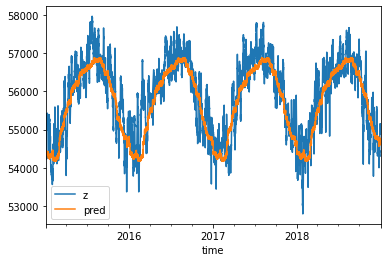

In [ ]:
y_copy.plot()

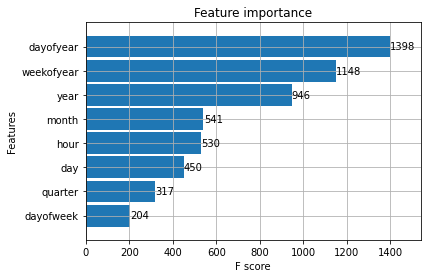

In [ ]:
plot_importance(xg, height=0.9)

####Predicting for the future

In [ ]:
date = pd.date_range(start="2019-01-01",end="2020-01-01")
date

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-05', '2019-01-06', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10',
               ...
               '2019-12-23', '2019-12-24', '2019-12-25', '2019-12-26',
               '2019-12-27', '2019-12-28', '2019-12-29', '2019-12-30',
               '2019-12-31', '2020-01-01'],
              dtype='datetime64[ns]', length=366, freq='D')

In [ ]:
future_df = pd.DataFrame(index=date)
features(future_df)

,hour,dayofweek,quarter,month,year,dayofyear,day,weekofyear
2019-01-01,0,1,1,1,2019,1,1,1
2019-01-02,0,2,1,1,2019,2,2,1
2019-01-03,0,3,1,1,2019,3,3,1
2019-01-04,0,4,1,1,2019,4,4,1
2019-01-05,0,5,1,1,2019,5,5,1
...,...,...,...,...,...,...,...,...
2019-12-28,0,5,4,12,2019,362,28,52
2019-12-29,0,6,4,12,2019,363,29,52
2019-12-30,0,0,4,12,2019,364,30,1
2019-12-31,0,1,4,12,2019,365,31,1


In [ ]:
future_pred = xg.predict(future_df)
future_pred = pd.DataFrame(data=future_pred,index=date)

In [ ]:
future_pred

,0
2019-01-01,54371.769531
2019-01-02,54379.582031
2019-01-03,54373.984375
2019-01-04,54358.972656
2019-01-05,54356.078125
...,...
2019-12-28,54600.875000
2019-12-29,54609.417969
2019-12-30,54707.078125
2019-12-31,54713.414062


In [ ]:
# The column name for geopotential is 0, but we want it to be z, so let's rename it
future_pred.columns = ['z']

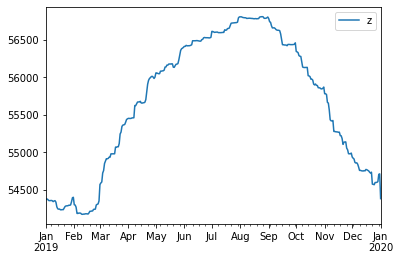

In [ ]:
# This is a plot of future predictions of a year
future_pred.plot()

#Model #2

This next model is very similar to the last, but is more advanced to get a better RMSE score.

In [ ]:
data = z500.z.sel(lon='78.75',lat='42.1875')
data = data.sel(time=slice('2000','2018'))

In [ ]:
df = data.to_dataframe()

In [ ]:
df = df.drop(['level','lon','lat'],axis=1)

In [ ]:
df

,z
time,
2000-01-01 00:00:00,55102.500000
2000-01-01 01:00:00,55110.171875
2000-01-01 02:00:00,55125.500000
2000-01-01 03:00:00,55171.515625
2000-01-01 04:00:00,55179.191406
...,...
2018-12-31 19:00:00,54983.343750
2018-12-31 20:00:00,54960.375000
2018-12-31 21:00:00,54975.687500


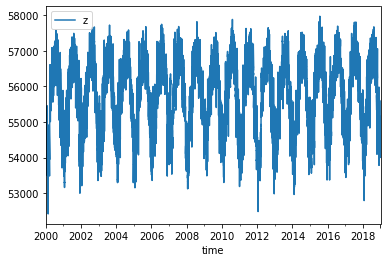

In [ ]:
df.plot()

# this is a seasonality trend

In [ ]:
def features(df):
  df['hour']=df.index.hour
  df['dayofweek']=df.index.dayofweek
  df['quarter'] = df.index.quarter
  df['month'] = df.index.month
  df['year'] = df.index.year
  df['dayofyear'] = df.index.dayofyear
  df['day'] = df.index.day
  df['weekofyear'] = df.index.isocalendar().week.astype(int)
  return df

In [ ]:
features(df)

,z,hour,dayofweek,quarter,month,year,dayofyear,day,weekofyear
time,,,,,,,,,
2000-01-01 00:00:00,55102.500000,0,5,1,1,2000,1,1,52
2000-01-01 01:00:00,55110.171875,1,5,1,1,2000,1,1,52
2000-01-01 02:00:00,55125.500000,2,5,1,1,2000,1,1,52
2000-01-01 03:00:00,55171.515625,3,5,1,1,2000,1,1,52
2000-01-01 04:00:00,55179.191406,4,5,1,1,2000,1,1,52
...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,54983.343750,19,0,4,12,2018,365,31,1
2018-12-31 20:00:00,54960.375000,20,0,4,12,2018,365,31,1
2018-12-31 21:00:00,54975.687500,21,0,4,12,2018,365,31,1


In [ ]:
df['lag']= df['z'].shift(1)
df

,z,hour,dayofweek,quarter,month,year,dayofyear,day,weekofyear,lag
time,,,,,,,,,,
2000-01-01 00:00:00,55102.500000,0,5,1,1,2000,1,1,52,NaN
2000-01-01 01:00:00,55110.171875,1,5,1,1,2000,1,1,52,55102.500000
2000-01-01 02:00:00,55125.500000,2,5,1,1,2000,1,1,52,55110.171875
2000-01-01 03:00:00,55171.515625,3,5,1,1,2000,1,1,52,55125.500000
2000-01-01 04:00:00,55179.191406,4,5,1,1,2000,1,1,52,55171.515625
...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,54983.343750,19,0,4,12,2018,365,31,1,54991.000000
2018-12-31 20:00:00,54960.375000,20,0,4,12,2018,365,31,1,54983.343750
2018-12-31 21:00:00,54975.687500,21,0,4,12,2018,365,31,1,54960.375000


In [ ]:
X = df[['hour','dayofweek','quarter','month','year','dayofyear','day', 'weekofyear','lag']].values
y = df[['z']].values

In [ ]:
# Keep in mind, this may take a few minutes
param_grid = {
    'min_samples_leaf': [1,2,3],
    'max_leaf_nodes': [10, 20, 30],
    'subsample':[0.5,0.6,0.7]
    }
reg = xgb.XGBRegressor()
gs = GridSearchCV(reg, param_grid, cv=5)
gs.fit(X_train, y_train)

In [ ]:
print(gs.best_params_)

In [ ]:
kf = KFold(n_splits=5, shuffle=True)
score = []
for train_index, test_index in kf.split(X):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]
  reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       min_samples_leaf=1,
                       max_leaf_nodes=10,
                       n_estimators=3000,
                       early_stopping_rounds=10,
                       max_depth=3,
                       colsample_bytree = 0.4,
                       subsample = 0.7,
                       learning_rate=0.01)
  reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100)
  y_pred = reg.predict(X_test)
  score.append(np.sqrt(mean_squared_error(y_test, y_pred)))

[01:07:19] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[0]	validation_0-rmse:55248.9	validation_1-rmse:55256.1
[100]	validation_0-rmse:20227.3	validation_1-rmse:20230.6
[200]	validation_0-rmse:7409.76	validation_1-rmse:7410.93
[300]	validation_0-rmse:2722.94	validation_1-rmse:2723.48
[400]	validation_0-rmse:1019.49	validation_1-rmse:1019.89
[500]	validation_0-rmse:419.144	validation_1-rmse:419.638
[600]	validation_0-rmse:229.023	validation_1-rmse:229.739
[700]	validation_0-rmse:173.846	validation_1-rmse:174.655
[800]	validation_0-rmse:153.758	validation_1-rmse:154.607
[900]	validation_0-rmse:140.815	validation_1-rmse:141.667
[1000]	validation_0-rmse:127.71	validation_1-rmse:128.565
[1100]	validation_0-rmse:119.003	validation_1-rmse:119.901
[1200]	validation_0-rmse:110.355	validation_1-rmse:111.303
[1300]	validation_0-rmse:104.743	validation_1-rmse:105.715
[1400]	validation_0-rmse:95.144	validation_1-rmse:96.2017
[1

In [ ]:
print("All scores:",score)
print("Average score:",np.mean(score))
print("Best RMSE score",min(score))

All scores: [45.245277, 43.217426, 43.409336, 43.384174, 43.39037]
Average score: 43.729317
Best RMSE score 43.217426


In [ ]:
y_pred = reg.predict(X_test)

In [ ]:
y_test = pd.DataFrame(y_test)

In [ ]:
y_test['pred']=y_pred

In [ ]:
y_test.columns = ['z','pred']

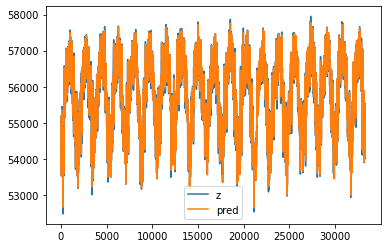

In [ ]:
y_test.plot()
# z values show up at extreme values / peaks (model could be less likely to predict real extreme values)

In [ ]:
date = pd.date_range(start="2019-01-01",end="2020-01-01")

In [ ]:
future_df = pd.DataFrame(index=date)

In [ ]:
features(future_df)

,hour,dayofweek,quarter,month,year,dayofyear,day,weekofyear
2019-01-01,0,1,1,1,2019,1,1,1
2019-01-02,0,2,1,1,2019,2,2,1
2019-01-03,0,3,1,1,2019,3,3,1
2019-01-04,0,4,1,1,2019,4,4,1
2019-01-05,0,5,1,1,2019,5,5,1
...,...,...,...,...,...,...,...,...
2019-12-28,0,5,4,12,2019,362,28,52
2019-12-29,0,6,4,12,2019,363,29,52
2019-12-30,0,0,4,12,2019,364,30,1
2019-12-31,0,1,4,12,2019,365,31,1


In [ ]:
future_df['lag']= df['z'].shift(1)

In [ ]:
future_df = future_df.values

In [ ]:
future_pred = reg.predict(future_df)

In [ ]:
future_pred = pd.DataFrame(data=future_pred,index=date)

In [ ]:
future_pred

,0
2019-01-01,55262.964844
2019-01-02,55266.859375
2019-01-03,55266.964844
2019-01-04,55267.132812
2019-01-05,55268.199219
...,...
2019-12-28,55466.785156
2019-12-29,55468.402344
2019-12-30,55527.609375
2019-12-31,55525.082031


In [ ]:
future_pred.columns = ['z']

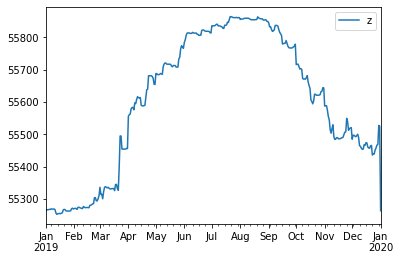

In [ ]:
future_pred.plot()

Model#3 with lag features

In [ ]:
data = z500.z.sel(lon='0',lat='8.4375')
data = data.sel(time=slice('2000','2018'))
df = data.to_dataframe()

In [ ]:
df = df.drop(['level','lon','lat'],axis=1)

In [ ]:
df['lag'] = df['z'].shift(1)
df['lag2'] = df['z'].shift(2)
df['lag3'] = df['z'].shift(3)
df['lag4'] = df['z'].shift(4)
df['lag5'] = df['z'].shift(5)
df['lag6'] = df['z'].shift(6)
df['lag7'] = df['z'].shift(7)
df['lag8'] = df['z'].shift(8)
df['lag9'] = df['z'].shift(9)
df['lag10'] = df['z'].shift(10)
df['lag11'] = df['z'].shift(11)
df['lag12'] = df['z'].shift(12)
df['lag13'] = df['z'].shift(13)
df['lag14'] = df['z'].shift(14)

In [ ]:
df

,z,lag,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14
time,,,,,,,,,,,,,,,
2000-01-01 00:00:00,57234.328125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-01 01:00:00,57142.296875,57234.328125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-01 02:00:00,57103.953125,57142.296875,57234.328125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-01 03:00:00,57050.281250,57103.953125,57142.296875,57234.328125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-01 04:00:00,57042.609375,57050.281250,57103.953125,57142.296875,57234.328125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00,57755.000000,57693.750000,57647.812500,57578.906250,57571.250000,57578.90625,57594.21875,57663.12500,57732.03125,57777.96875,57747.34375,57732.03125,57663.12500,57609.53125,57571.25000
2018-12-31 20:00:00,57816.250000,57755.000000,57693.750000,57647.812500,57578.906250,57571.25000,57578.90625,57594.21875,57663.12500,57732.03125,57777.96875,57747.34375,57732.03125,57663.12500,57609.53125
2018-12-31 21:00:00,57816.250000,57816.250000,57755.000000,57693.750000,57647.812500,57578.90625,57571.25000,57578.90625,57594.21875,57663.12500,57732.03125,57777.96875,57747.34375,57732.03125,57663.12500


In [ ]:
df = df.dropna()

In [ ]:
X= df[['lag','lag2','lag3','lag4','lag5','lag6','lag7','lag8','lag9','lag10','lag11','lag12','lag13','lag14']]
y = df[['z']]

In [ ]:
X_train =
X_test =
y_train =
y_test =
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=22)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
X_test

,lag,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14
time,,,,,,,,,,,,,,
2007-02-18 23:00:00,57389.156250,57373.859375,57312.687500,57274.453125,57251.500000,57213.265625,57205.625000,57243.859375,57259.156250,57312.687500,57335.625000,57404.453125,57373.859375,57373.859375
2016-06-28 16:00:00,57699.062500,57737.359375,57768.000000,57783.328125,57790.984375,57829.296875,57798.656250,57752.687500,57699.062500,57676.078125,57645.421875,57645.421875,57645.421875,57653.093750
2008-04-01 06:00:00,57190.296875,57205.609375,57228.578125,57243.890625,57305.125000,57374.031250,57458.250000,57465.906250,57427.625000,57412.312500,57366.375000,57312.781250,57289.812500,57251.546875
2013-10-19 14:00:00,57545.531250,57560.828125,57614.375000,57660.265625,57629.671875,57591.421875,57507.296875,57461.406250,57423.156250,57407.859375,57438.453125,57453.750000,57530.234375,57568.484375
2016-09-17 17:00:00,57446.250000,57415.593750,57484.546875,57530.515625,57614.781250,57637.765625,57676.078125,57676.078125,57645.421875,57545.828125,57553.500000,57515.187500,57507.531250,57530.515625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-10-11 15:00:00,57413.750000,57459.656250,57497.906250,57559.109375,57559.109375,57582.062500,57543.812500,57474.953125,57467.296875,57429.046875,57436.703125,57459.656250,57513.203125,57582.062500
2015-12-13 18:00:00,57539.796875,57516.796875,57539.796875,57593.437500,57647.062500,57716.031250,57762.015625,57777.343750,57746.687500,57662.390625,57616.421875,57562.781250,57570.437500,57555.109375
2018-11-21 11:00:00,57892.812500,57846.875000,57785.625000,57709.062500,57655.468750,57609.531250,57578.906250,57586.562500,57609.531250,57686.093750,57755.000000,57831.562500,57846.875000,57808.593750


In [ ]:
mean_squared_error(y_test,y_pred)

576.42426

Next model

In [ ]:
data = z500.z.sel(lon='0',lat='8.4375')
data = data.sel(time=slice('2000','2018'))
df = data.to_dataframe()
df = df.drop(['level','lon','lat'],axis=1)

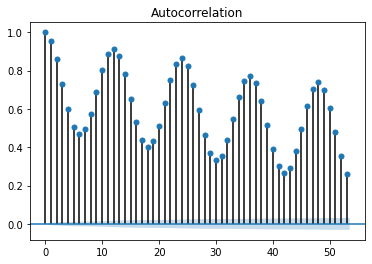

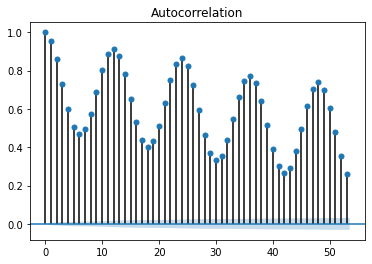

In [ ]:
plot_acf(df)

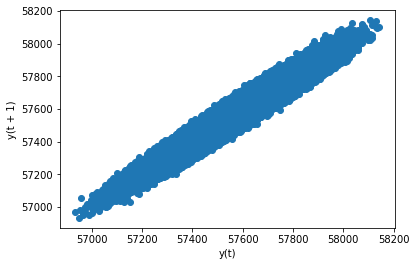

In [ ]:
lag_plot(df)

In [ ]:
# which models show off best aspects of analysis
# models with interesting contrast

In [ ]:
!pip install neuralprophet

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 98 kB 3.4 MB/s 


In [ ]:
from neuralprophet import NeuralProphet

In [ ]:
data = z500.z.sel(lon='0',lat='-8.4375')
data = data.sel(time=slice('2010','2018'))

In [ ]:
df = data.to_dataframe()
df = df.drop(['level','lon','lat'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 78888 entries, 2010-01-01 00:00:00 to 2018-12-31 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   z       78888 non-null  float32
dtypes: float32(1)
memory usage: 924.5 KB


In [ ]:
df['ds']= df.index

In [ ]:
df = df.rename(columns={'z': 'y'})

In [ ]:
m = NeuralProphet(yearly_seasonality=True)
# n_changepoints — specifies the number of points where the broader trend (rate of increase/decrease) in the data changes.
#trend_reg — a regularization parameter that controls the flexibility of changepoint selection. Larger values (~1–100) will limit the variability of changepoints. Smaller values (~0.001–1.0) will allow for more variability in changepoints.

In [ ]:
train, val = m.split_df(df, freq='H')

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.999% of the data.
INFO:NP.df_utils:Major frequency H corresponds to 99.999% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


In [ ]:
metrics = m.fit(train, freq='H', validation_df=val)

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.998% of the data.
INFO:NP.df_utils:Major frequency H corresponds to 99.998% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO:NP.config:Setting normalization to global as only one dataframe provided for training.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 64
INFO:NP.config:Auto-set batch_size to 64
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 64
INFO:NP.config:Auto-set epochs to 64


  0%|          | 0/170 [00:00<?, ?it/s]

INFO - (NP.utils_torch.lr_range_test) - lr-range-test results: steep: 6.38E-02, min: 1.33E-01
INFO:NP.utils_torch:lr-range-test results: steep: 6.38E-02, min: 1.33E-01


  0%|          | 0/170 [00:00<?, ?it/s]

INFO - (NP.utils_torch.lr_range_test) - lr-range-test results: steep: 7.21E-02, min: 1.50E-01
INFO:NP.utils_torch:lr-range-test results: steep: 7.21E-02, min: 1.50E-01
INFO - (NP.forecaster._init_train_loader) - lr-range-test selected learning rate: 7.72E-02
INFO:NP.forecaster:lr-range-test selected learning rate: 7.72E-02
  0%|          | 0/64 [00:00<?, ?it/s]Using a target size (torch.Size([1024])) that is different to the input size (torch.Size([1024, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
Using a target size (torch.Size([417])) that is different to the input size (torch.Size([417, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
Epoch[64/64]: 100%|██████████| 64/64 [01:47<00:00,  1.68s/it, SmoothL1Loss=0.00605, MAE=81.4, RMSE=101, Loss=0.00458, RegLoss=0, MAE_val=126, RMSE_val=156, SmoothL1Loss_val=0.0145]


In [ ]:
metrics.tail(1)

,SmoothL1Loss,MAE,RMSE,Loss,RegLoss,SmoothL1Loss_val,MAE_val,RMSE_val
63,0.006051,81.382475,101.454556,0.004582,0.0,0.014461,125.701738,155.989779


In [ ]:
future = m.make_future_dataframe(df, periods=24,n_historic_predictions=len(df))

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.999% of the data.
INFO:NP.df_utils:Major frequency H corresponds to 99.999% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


In [ ]:
forecast = m.predict(future)

INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.999% of the data.
INFO:NP.df_utils:Major frequency H corresponds to 99.999% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils._infer_frequency) - Major frequency H corresponds to 99.999% of the data.
INFO:NP.df_utils:Major frequency H corresponds to 99.999% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - H
INFO:NP.df_utils:Defined frequency is equal to major frequency - H
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO:NP.df_utils:Returning df with no ID column


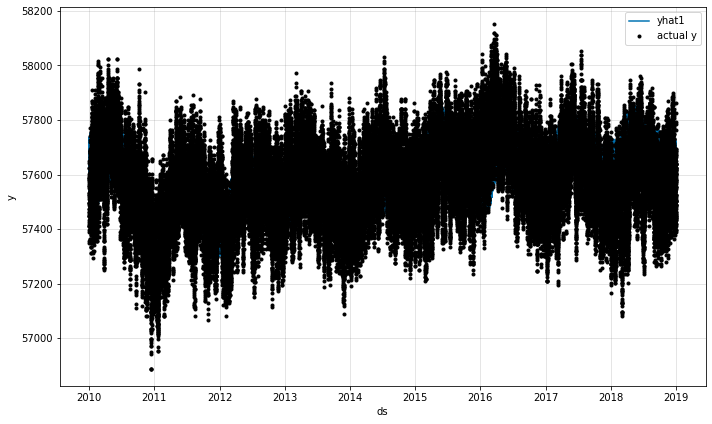

In [ ]:
forecast_plot = m.plot(forecast)

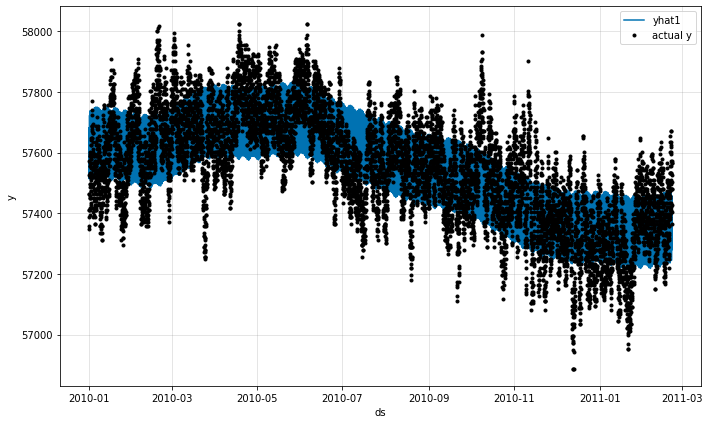

In [ ]:
forecast_plot = m.plot(forecast[:10000])

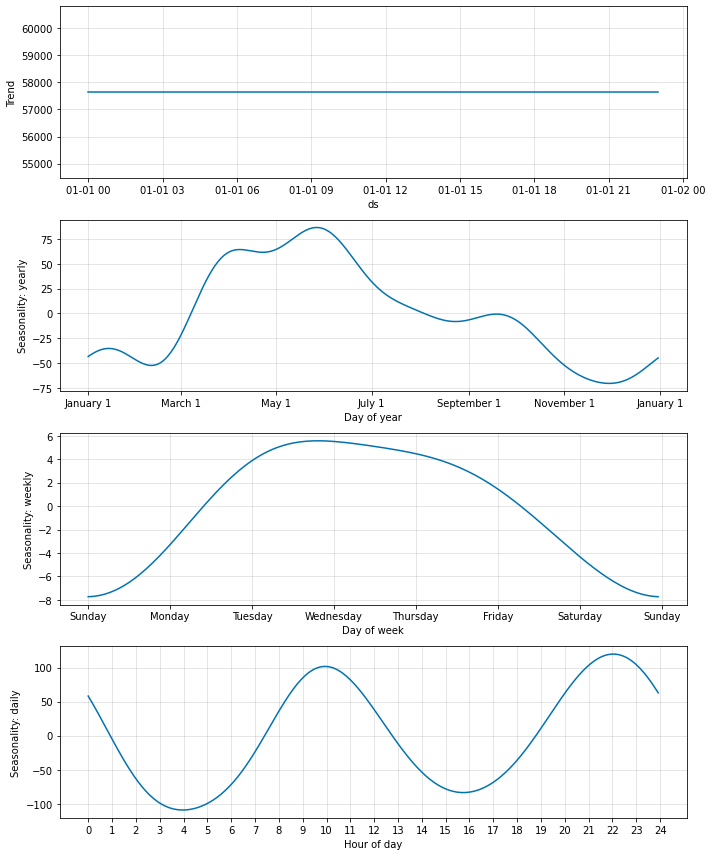

In [ ]:
component_plot = m.plot_components(future_pred)

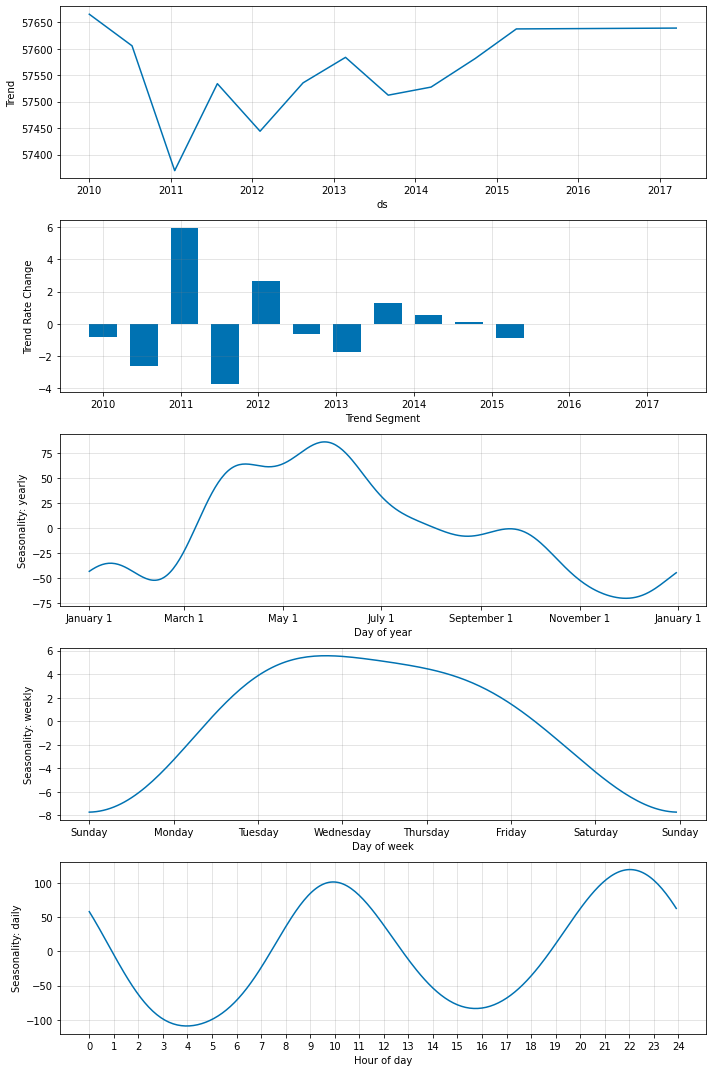

In [ ]:
parameter_plot = m.plot_parameters()

In [ ]:
data = z500.z.sel(lon='0',lat='87.1875')
data = data.sel(time=slice('2015','2018'))
df = data.to_dataframe()
df = df.drop(['level','lon','lat'],axis=1)

In [ ]:
from statsmodels.tsa.stattools import adfuller

<AxesSubplot:xlabel='time'>

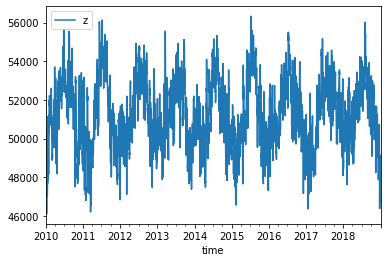

In [ ]:
df.plot()

In [ ]:
test = adfuller(df, autolag='AIC')

In [ ]:
print(f"""ADF Statistic: {test[0]}
      p_value: {test[1]}
      """)
for key, value in test[4].items():
    print('Critial Values:')
    print(f' {key}, {value}')

ADF Statistic: -10.552572695236641
      p_value: 8.104637580608588e-19
      
Critial Values:
 1%, -3.430432964527751
Critial Values:
 5%, -2.8615766689129027
Critial Values:
 10%, -2.5667895175981226


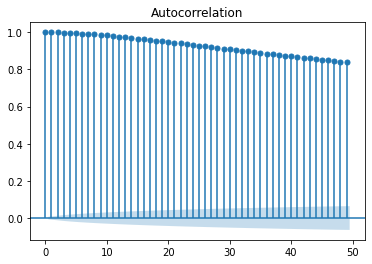

In [ ]:
acf = plot_acf(df)

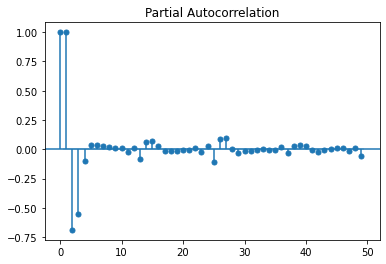

In [ ]:
pacf = plot_pacf(df)

Feel free to continue coding and exploring!

## Thanks for checking this guide out! Congratulations on finishing.

### *Some additional resources to explore:*

**Climate Science/Modelling:**
* *Real Climate*, a climate science blog by experts: https://www.realclimate.org/
* Professor Steve Easterbrook's Blog, Serendipity: https://www.easterbrook.ca/steve/about/


**Other Climate Datasets:**

*   List item
*   List item




Stephan Rasp, Peter D. Dueben, Sebastian Scher, Jonathan A. Weyn, Soukayna Mouatadid, and Nils Thuerey, 2020. WeatherBench: A benchmark dataset for data-driven weather forecasting. arXiv: https://arxiv.org/abs/2002.00469